In [19]:
import torch
import torch.nn as nn  
import matplotlib.pyplot as plt

In [20]:
X = torch.arange(0,10, dtype=torch.float32).unsqueeze(1)
y = 3 * X + 2


train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [21]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
        self.linear_layer.weight.requires_grad_(True)
        self.linear_layer.bias.requires_grad_(True)

    def forward(self, X):
        return self.linear_layer(X)

In [22]:
model = LinearRegressionModel()

loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(),lr = 0.001)

In [23]:
epochs = 1000

for epoch in range(epochs):

  y_pred = model(X)

  loss = loss_fn(y_pred, y)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss}")
  

Epoch: 0 | Loss: 280.37518310546875
Epoch: 10 | Loss: 84.5447998046875
Epoch: 20 | Loss: 25.806482315063477
Epoch: 30 | Loss: 8.184707641601562
Epoch: 40 | Loss: 2.8946099281311035
Epoch: 50 | Loss: 1.303067684173584
Epoch: 60 | Loss: 0.8208467364311218
Epoch: 70 | Loss: 0.6713902950286865
Epoch: 80 | Loss: 0.6217886805534363
Epoch: 90 | Loss: 0.6021890640258789
Epoch: 100 | Loss: 0.5916406512260437
Epoch: 110 | Loss: 0.5838593244552612
Epoch: 120 | Loss: 0.5769601464271545
Epoch: 130 | Loss: 0.5703762769699097
Epoch: 140 | Loss: 0.563937783241272
Epoch: 150 | Loss: 0.5575934052467346
Epoch: 160 | Loss: 0.551326334476471
Epoch: 170 | Loss: 0.5451322197914124
Epoch: 180 | Loss: 0.5390076637268066
Epoch: 190 | Loss: 0.5329522490501404
Epoch: 200 | Loss: 0.526965320110321
Epoch: 210 | Loss: 0.5210452675819397
Epoch: 220 | Loss: 0.5151917338371277
Epoch: 230 | Loss: 0.5094035863876343
Epoch: 240 | Loss: 0.5036811232566833
Epoch: 250 | Loss: 0.4980227053165436
Epoch: 260 | Loss: 0.492427766

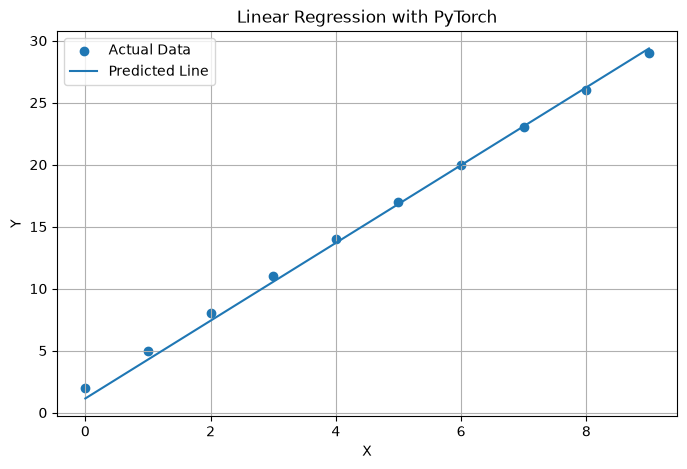

In [25]:
with torch.no_grad():
    predictions = model(X)
    
plt.figure(figsize=(8, 5))

# Original data
plt.scatter(
    X.numpy(),
    y.numpy(),
    label="Actual Data"
)

# Learned regression line
plt.plot(
    X.numpy(),
    predictions.numpy(),
    label="Predicted Line"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression with PyTorch")

plt.legend()
plt.grid(True)

plt.show()